In [ ]:
import os
from google.colab import drive
import scipy.io
import numpy as np
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
from keras.applications import  MobileNet
from tensorflow import keras
from keras import models, layers
from keras.models import Model
from keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.regularizers import l2


In [ ]:
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
image_path = '/content/gdrive/MyDrive/flowers/'

In [ ]:
files = os.listdir(image_path)
files = [item for item in files if ')' not in item]
images = [item for item in files if 'ipynb_checkpoints' not in item]
print("Number of images in dataset:",len(images))

Number of images in dataset: 8189


In [ ]:
images.sort()


In [ ]:
print(f"images: {images[:5]}...")

images: ['image_00001.jpg', 'image_00002.jpg', 'image_00003.jpg', 'image_00004.jpg', 'image_00005.jpg']...


In [ ]:
labels = scipy.io.loadmat('/content/gdrive/MyDrive/imagelabels.mat')
splits = scipy.io.loadmat('/content/gdrive/MyDrive/setid.mat')

print("labels type : ", type(labels))
print("splits type: ", type(splits))

labels type :  <class 'dict'>
splits type:  <class 'dict'>


In [ ]:

label = labels['labels']

print("Length of Labels:", label.size)

print("***Printing length of set id's of training testing and validation set***")

print('Length of Testing set:', splits['trnid'].size)
print('Length of Training set : ', splits['tstid'].size)
print('Length of validation set:', splits['valid'].size)

Length of Labels: 8189
***Printing length of set id's of training testing and validation set***
Length of Testing set: 1020
Length of Training set :  6149
Length of validation set: 1020


In [ ]:
sets = ['../content/Training', '../content/Testing', '../content/Validation']

for i in sets:
    os.mkdir(i)
    for j in range(1, 103):
        os.mkdir(i + f'/{j}')

FileExistsError: ignored

In [ ]:
import shutil

def copy_images(image_ids, images, image_path, destination_folder, label):
    for img_id in image_ids:
        img = images[img_id - 1]
        source = image_path + img
        destination = f"../content/{destination_folder}/{label[0][img_id-1]}"
        shutil.copy(source, destination)

def split_and_copy_images(splits, images, image_path, label):
    print("Start splitting....")

    print("Copying testing data.....")
    copy_images(splits['trnid'][0], images, image_path, "Testing", label)

    print("Copying validation data.....")
    copy_images(splits['valid'][0], images, image_path, "Validation", label)

    print("Copying training data.....")
    copy_images(splits['tstid'][0], images, image_path, "Training", label)

    print("Splitting finished")

# Assuming the function is called with appropriate arguments:
split_and_copy_images(splits, images, image_path, label)



Start splitting....
Copying testing data.....
Copying validation data.....
Copying training data.....
Splitting finished


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
)

train_generator = train_datagen.flow_from_directory(
    '../content/Training',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb'
)

# Validation ImageDataGenerator
valid_datagen = ImageDataGenerator(rescale=1./255)

valid_generator = valid_datagen.flow_from_directory(
    '../content/Validation',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
)

# Testing ImageDataGenerator
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '../content/Testing',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
)

Found 6149 images belonging to 102 classes.
Found 1020 images belonging to 102 classes.
Found 1020 images belonging to 102 classes.


In [ ]:
base_model = MobileNet(include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
predictions = Dense(102, activation='softmax')(x)

17225924/17225924 [==============================] - 0s 0us/step


In [ ]:
 model = Model(inputs=base_model.input, outputs=predictions)

 model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
early_stoping = EarlyStopping(monitor='val_loss',patience=3,verbose=1)

In [ ]:
history=model.fit(train_generator, epochs=20, validation_data=test_generator,callbacks=[early_stoping])

Epoch 1/20
193/193 [==============================] - 124s 594ms/step - loss: 3.6387 - accuracy: 0.2389 - val_loss: 2.8403 - val_accuracy: 0.3314
Epoch 2/20
193/193 [==============================] - 89s 459ms/step - loss: 2.2928 - accuracy: 0.4635 - val_loss: 1.8224 - val_accuracy: 0.5794
Epoch 3/20
193/193 [==============================] - 88s 454ms/step - loss: 1.6874 - accuracy: 0.5814 - val_loss: 1.2557 - val_accuracy: 0.7157
Epoch 4/20
193/193 [==============================] - 100s 518ms/step - loss: 1.3465 - accuracy: 0.6609 - val_loss: 0.9645 - val_accuracy: 0.7686
Epoch 5/20
193/193 [==============================] - 87s 450ms/step - loss: 1.0915 - accuracy: 0.7068 - val_loss: 0.9148 - val_accuracy: 0.7725
Epoch 6/20
193/193 [==============================] - 87s 453ms/step - loss: 0.9241 - accuracy: 0.7535 - val_loss: 0.7412 - val_accuracy: 0.8157
Epoch 7/20
193/193 [==============================] - 87s 453ms/step - loss: 0.8304 - accuracy: 0.7756 - val_loss: 0.6805 - val_

In [ ]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 112, 112, 32)     128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 112, 112, 32)     288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 112, 112, 32)     128       
 ation)                                                      

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

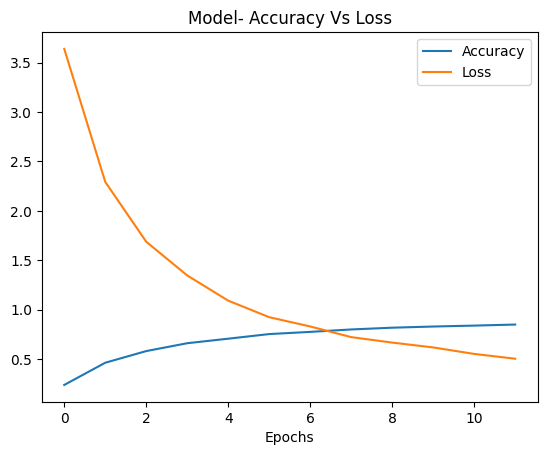

In [ ]:
plt.plot(range(len(model.history.history['accuracy'])),model.history.history['accuracy'])
plt.plot(range(len(model.history.history['loss'])),model.history.history['loss'])
plt.title('Model- Accuracy Vs Loss')
plt.xlabel('Epochs')
plt.legend(['Accuracy', 'Loss'])
plt.show()

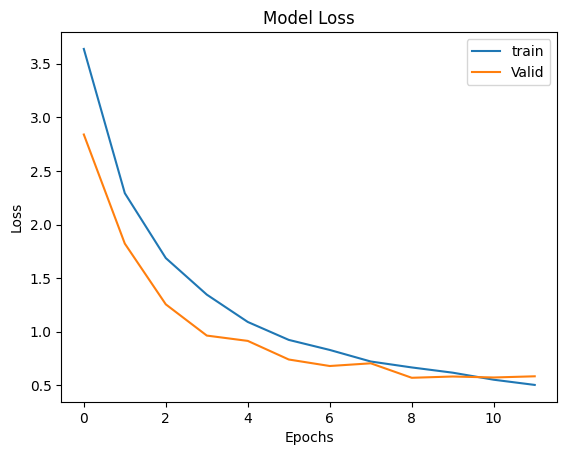

In [ ]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'Valid'])
plt.show()

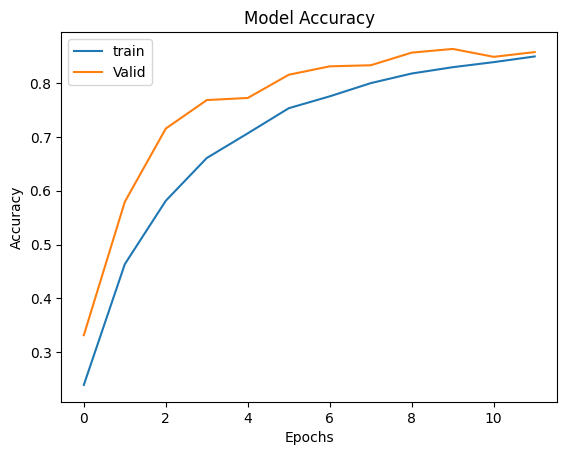

In [ ]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'Valid'])
plt.show()

In [ ]:
loss, accuracy = model.evaluate(valid_generator)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

32/32 [==============================] - 3s 92ms/step - loss: 0.4412 - accuracy: 0.8794
Test Loss: 0.4412, Test Accuracy: 0.8794


In [ ]:
label_names = ['pink primrose','hard-leaved pocket orchid','canterbury bells','sweet pea','english marigold','tiger lily','moon orchid','bird of paradise',
'monkshood','globe thistle','snapdragon',"colt's foot",'king protea','spear thistle','yellow iris','globe-flower',
'purple coneflower','peruvian lily','balloon flower','giant white arum lily','fire lily','pincushion flower','fritillary','red ginger',
'grape hyacinth','corn poppy','prince of wales feathers','stemless gentian','artichoke','sweet william','carnation','garden phlox','love in the mist',
'mexican aster','alpine sea holly','ruby-lipped cattleya','cape flower','great masterwort','siam tulip','lenten rose','barbeton daisy','daffodil',
'sword lily','poinsettia','bolero deep blue','wallflower','marigold','buttercup','oxeye daisy','common dandelion','petunia','wild pansy','primula',
'sunflower','pelargonium','bishop of llandaff','gaura','geranium','orange dahlia','pink-yellow dahlia?','cautleya spicata','japanese anemone',
'black-eyed susan','silverbush','californian poppy','osteospermum','spring crocus','bearded iris','windflower','tree poppy','gazania','azalea',
'water lily','rose','thorn apple','morning glory','passion flower','lotus','toad lily','anthurium','frangipani','clematis','hibiscus','columbine',
'desert-rose','tree mallow','magnolia','cyclamen ','watercress','canna lily','hippeastrum ','bee balm','ball moss','foxglove','bougainvillea',
'camellia','mallow','mexican petunia','bromelia','blanket flower','trumpet creeper','blackberry lily']

32/32 [==============================] - 6s 199ms/step
Predicted Class: pink primrose
Actual Class: pink primrose


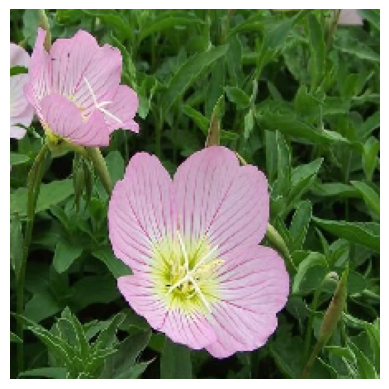

Predicted Class: pink primrose
Actual Class: pink primrose


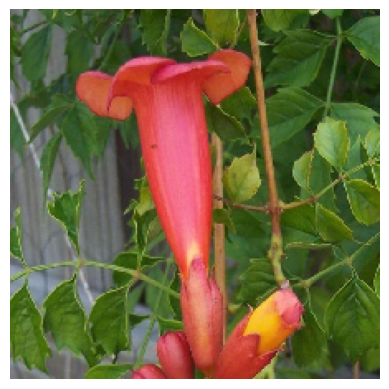

Predicted Class: pink primrose
Actual Class: pink primrose


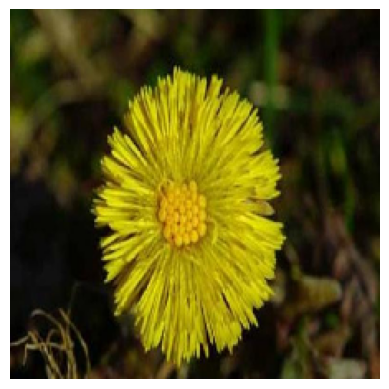

Predicted Class: desert-rose
Actual Class: pink primrose


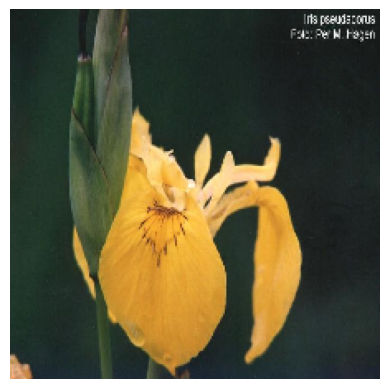

Predicted Class: pink primrose
Actual Class: pink primrose


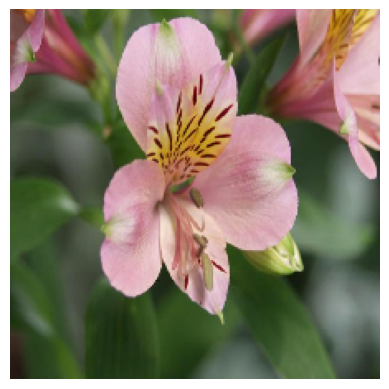

Predicted Class: pink primrose
Actual Class: pink primrose


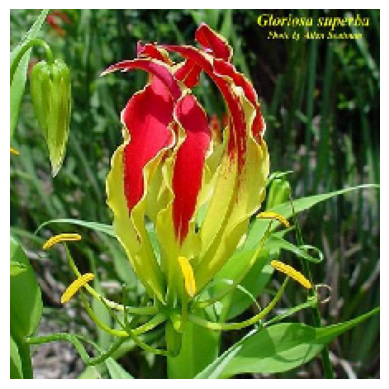

Predicted Class: pink primrose
Actual Class: pink primrose


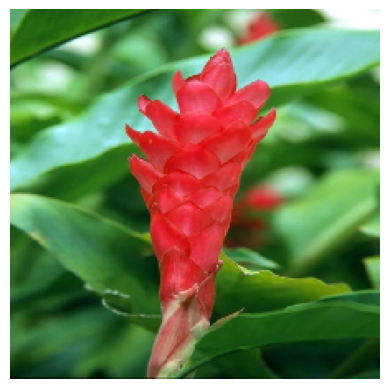

Predicted Class: pink primrose
Actual Class: pink primrose


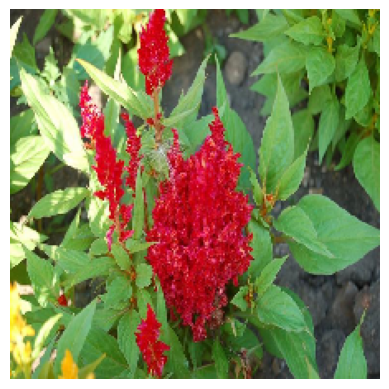

Predicted Class: hippeastrum 
Actual Class: pink primrose


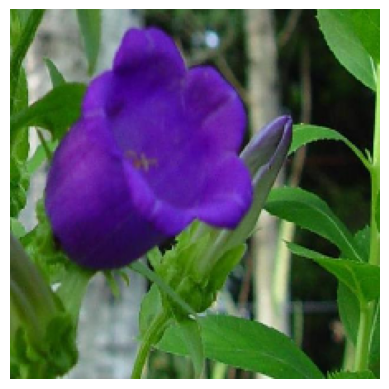

Predicted Class: pink-yellow dahlia?
Actual Class: pink primrose


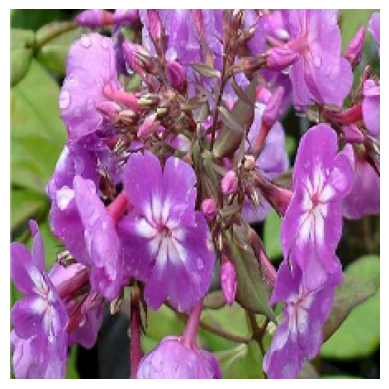

Predicted Class: hard-leaved pocket orchid
Actual Class: hard-leaved pocket orchid


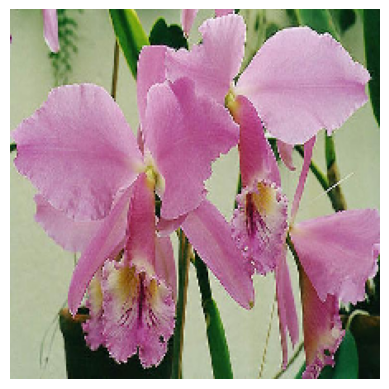

Predicted Class: hard-leaved pocket orchid
Actual Class: hard-leaved pocket orchid


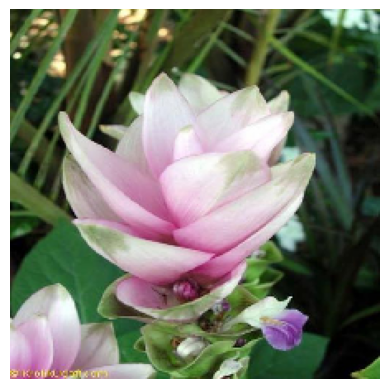

Predicted Class: hard-leaved pocket orchid
Actual Class: hard-leaved pocket orchid


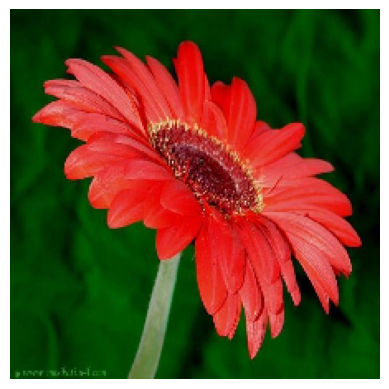

Predicted Class: hard-leaved pocket orchid
Actual Class: hard-leaved pocket orchid


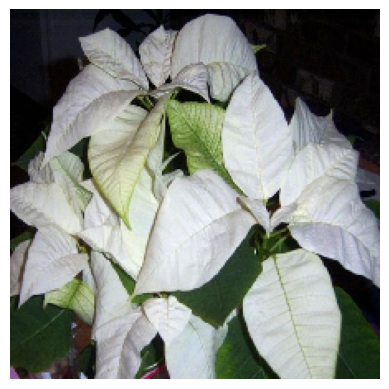

Predicted Class: hard-leaved pocket orchid
Actual Class: hard-leaved pocket orchid


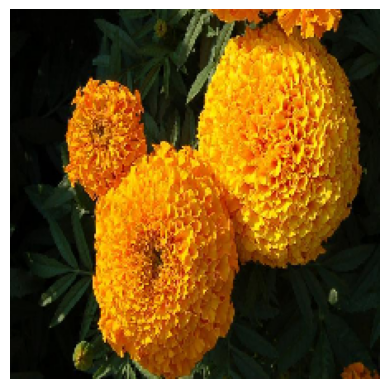

Predicted Class: hard-leaved pocket orchid
Actual Class: hard-leaved pocket orchid


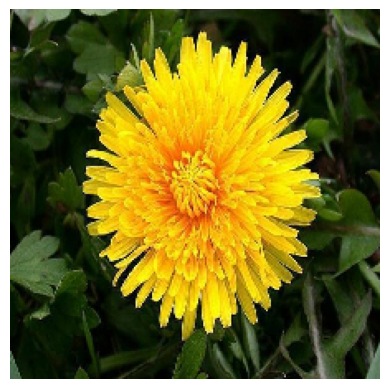

Predicted Class: hard-leaved pocket orchid
Actual Class: hard-leaved pocket orchid


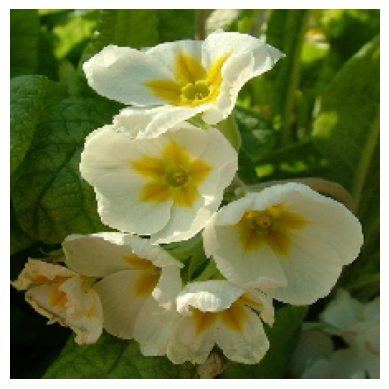

Predicted Class: hard-leaved pocket orchid
Actual Class: hard-leaved pocket orchid


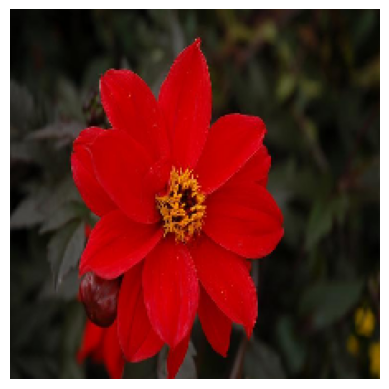

Predicted Class: hard-leaved pocket orchid
Actual Class: hard-leaved pocket orchid


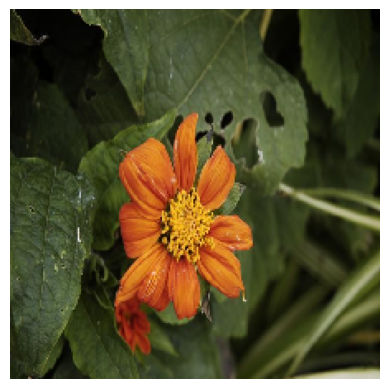

Predicted Class: oxeye daisy
Actual Class: hard-leaved pocket orchid


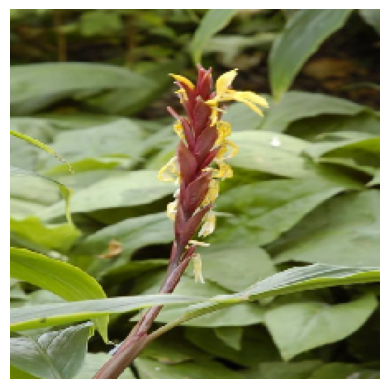

Predicted Class: canterbury bells
Actual Class: canterbury bells


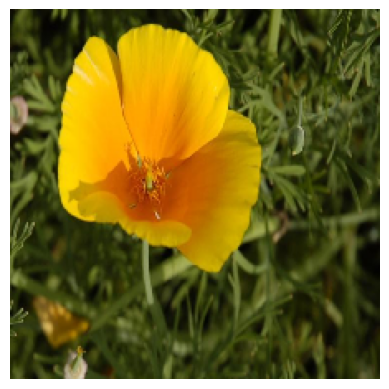

Predicted Class: canterbury bells
Actual Class: canterbury bells


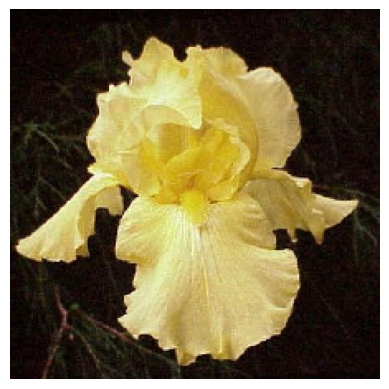

Predicted Class: azalea
Actual Class: canterbury bells


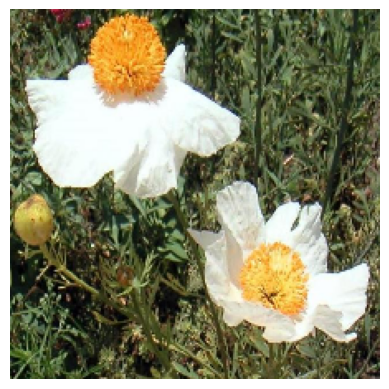

Predicted Class: canterbury bells
Actual Class: canterbury bells


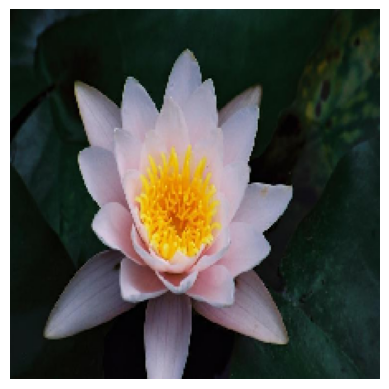

Predicted Class: canterbury bells
Actual Class: canterbury bells


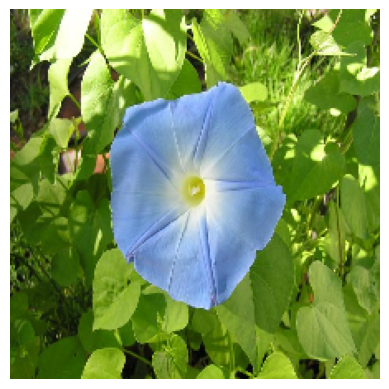

Predicted Class: canterbury bells
Actual Class: canterbury bells


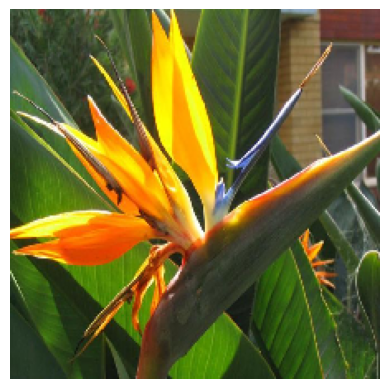

Predicted Class: canterbury bells
Actual Class: canterbury bells


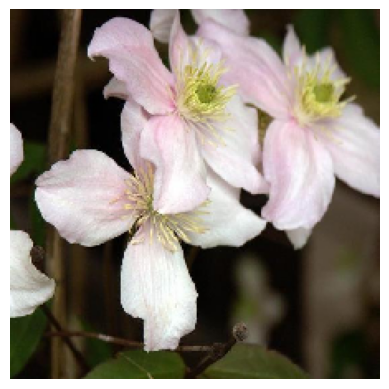

Predicted Class: canterbury bells
Actual Class: canterbury bells


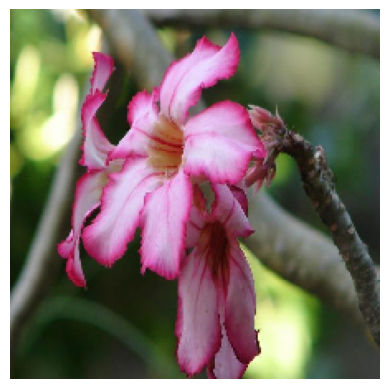

Predicted Class: canterbury bells
Actual Class: canterbury bells


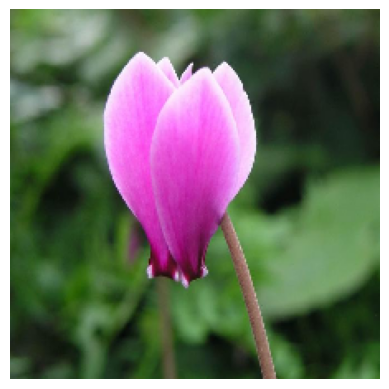

Predicted Class: canterbury bells
Actual Class: canterbury bells


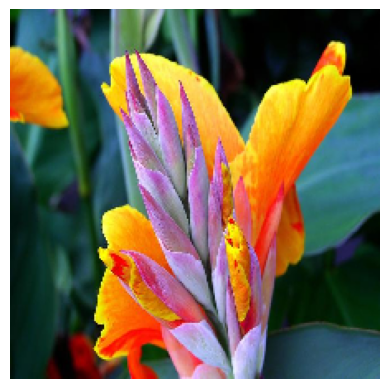

Predicted Class: sweet pea
Actual Class: sweet pea


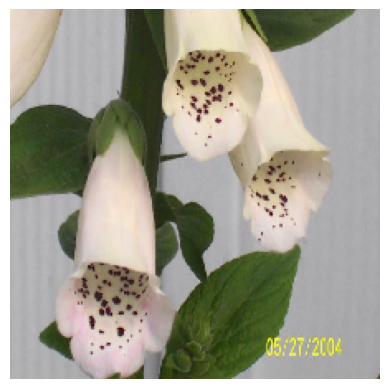

Predicted Class: thorn apple
Actual Class: sweet pea


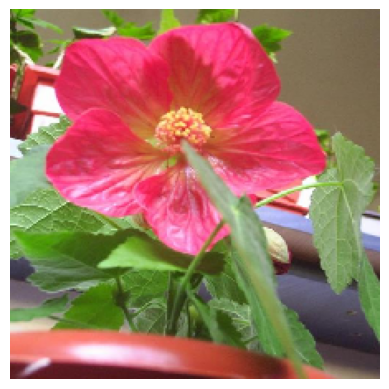

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Assuming you have a trained model named 'model',
# a validation data generator named 'valid_generator',
# a list of flower names named 'label_names', and
# the 'valid_generator' labels are in the range of 0 to 101.

# Make predictions using the model on the validation data
predictions = model.predict(valid_generator)

# Convert predictions from probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the true labels from the validation data generator
true_labels = valid_generator.classes

# Loop through the validation data generator and plot images
for i in range(len(valid_generator)):
    x, _ = valid_generator[i]  # Ignore the second variable (labels)

    # Plot the image
    plt.imshow(image.array_to_img(x[0]))  # Assuming batch size is 1
    plt.axis('off')

    # Get the predicted and actual class labels
    predicted_class = label_names[predicted_labels[i]]
    actual_class = label_names[true_labels[i]]

    # Print the predicted and actual classes
    print(f"Image {i + 1}: Predicted Class: {predicted_class}, Actual Class: {actual_class}")

    # Show the plot
    plt.show()

In this updated code, we use an underscore _ as a placeholder for the second variable in the generator, which is the label variable y that we don't need in this context. This way, we only get the input images x from the generator.

The code should now display the images along with their predicted and actual classes correctly. The loop variable i corresponds to the current index of the image in the generator.

Please give this code a try, and if you still encounter any issues or have further questions, feel free to let me know.





In [ ]:
label[0]

array([77, 77, 77, ..., 62, 62, 62], dtype=uint8)

In [ ]:
valid_generator.labels

array([  0,   0,   0, ..., 101, 101, 101], dtype=int32)

In [ ]:
x,y = valid_generator[25]

In [ ]:
len(valid_generator)

32

In [ ]:
valid_generator.classes

array([  0,   0,   0, ..., 101, 101, 101], dtype=int32)